## Attribute Inference Attacks with Custom Models and Group-wise Risks

In this notebook, we focus on attribute inference attacks and additional features provided by `Anonymeter`.

These extend the `InferenceEvaluator` by enabling more flexible privacy risk assessment.

In particular, we introduce support for custom models, allowing risk to be measured beyond the default kNN approach.  
This makes it possible to scale inference attacks to the full dataset, which is not feasible with kNN due to computational constraints.

The second feature introduces group-wise risk estimation.  
For a given target (secret) column (e.g., `income` ∈ {`>50K`, `<=50K`}), the risk is computed separately for each group.  
This enables further analyses, such as assessing fairness across different subpopulations.

In [2]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

from anonymeter.evaluators import InferenceEvaluator
from anonymeter.evaluators.sklearn_inference_predictor import SklearnInferencePredictor

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Downloading the data

For this example, we will use the famous `Adults` (more details [here](https://archive.ics.uci.edu/ml/datasets/adult)) dataset. This dataset contains aggregated census data, where every row represent a population segment. For the purpose of demonstrating `Anonymeter`, we will use this data as if each row would in fact refer to a real individual. 

The synthetic version has been generated by `CTGAN` from [SDV](https://sdv.dev/SDV/user_guides/single_table/ctgan.html), as explained in the paper accompanying this code release. For details on the generation process, e.g. regarding hyperparameters, see Section 6.2.1 of [the accompanying paper](https://petsymposium.org/popets/2023/popets-2023-0055.php)).

We pull these datasets from the [Statice](https://www.statice.ai/) public GC bucket:

In [4]:
dataset_dir = "./datasets/"

ori = pd.read_csv(os.path.join(dataset_dir, "adults_train.csv"))
syn = pd.read_csv(os.path.join(dataset_dir, "adults_syn_ctgan.csv"))
control = pd.read_csv(os.path.join(dataset_dir, "adults_control.csv"))

In [5]:
ori.head()

,age,type_employer,fnlwgt,education,education_num,marital,occupation,relationship,race,sex,capital_gain,capital_loss,hr_per_week,country,income
0,53,Self-emp-not-inc,138022,11th,7,Divorced,Craft-repair,Not-in-family,White,Male,0,0,60,United-States,<=50K
1,31,Private,344200,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
2,28,Private,242482,HS-grad,9,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,40,United-States,<=50K
3,26,Private,193165,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,52,United-States,>50K
4,27,Private,267989,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K


As visible the dataset contains several demographic information, as well as information regarding the education, financial situation, and personal life of some tens of thousands of "individuals".

## 1. Measuring the Inference Risk with a custom model

The goal is to allow users to pass custom models other than the default KNN neighbours in order to perform the attribute inference attack.

The requirements for the model are:

1. It is trained on the synthetic data with the `secret` as a target. (It can be a classification or regression model)
2. The inference model must implement our protocol that defines a predict(x) method returning predictions whose index matches that of x (anonymeter.evaluators.inference_predictor::InferencePredictor)
3. The model should be able to process the data within its own pipeline

The following example we use a DecisionTreeClassifier which is wrapped in our predefined SklearnInferencePredictor

The column `income` will be used as the secret in the following example, and the rest of the columns as auxiliary columns (aux_columns).

In [6]:
# Choose a target (the secret) column for the inference model
secret = "income"
# Select the input colums - aux_cols to train the inference model on
aux_cols = [col for col in ori.columns if col != secret]

# Data Preprocessing requirements
categorical_cols = ori[aux_cols].select_dtypes(include=["object"]).columns
numeric_cols = ori[aux_cols].select_dtypes(include=["number"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

# The inference model
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
)

# Build the pipeline out of the preprocessing step and inference model
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", tree)
])

# Fit the model
model.fit(ori[aux_cols], ori[secret])

# Wrap the model in an InferencePredictor (anonymeter.evaluators.inference_predictor::InferencePredictor)
# In this case we use our implemented SklearnInferencePredictor
inference_model = SklearnInferencePredictor(model)

Finally, to asssess the inference privacy risk, the inference_model from above should be passed as: 
`inference_model=inference_model` to the `InferenceEvaluator` like in the example below:

In [7]:
evaluator = InferenceEvaluator(ori=ori, 
                                syn=syn, 
                                control=control,
                                aux_cols=aux_cols,
                                secret=secret,
                                n_attacks=ori.shape[0], # the min value of n_attacks and ori.shape[0] is considered
                                regression = False,
                                inference_model=inference_model) # We pass the inference_model here
# Evaluate
evaluator.evaluate(n_jobs=-2)
result = evaluator.results()
print(f"Privacy risk for secret=[{secret}]: {result.risk()}")

Privacy risk for secret=[income]: PrivacyRisk(value=0.0368678447218772, ci=(0.0, 0.08019919194225494))


## 2. Measuring Group-wise Inference Risk

Using the `InferenceEvaluator` defined above for the secret column `income`, we can compute the group-wise risk for each value (`>50K`, `<=50K`).

This can be done by simply calling `risk_for_groups = evaluator.risk_for_groups()`

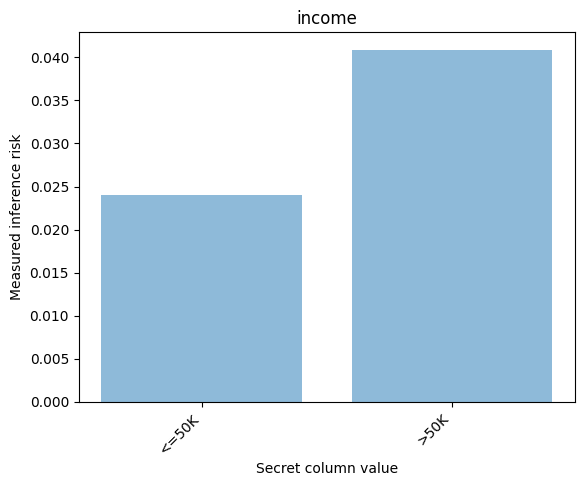

In [8]:
risk_for_groups = evaluator.risk_for_groups()

fig, ax = plt.subplots()
risks = [res.risk().value for _, res in risk_for_groups.items()]
cols = [key for key,_ in risk_for_groups.items()]

ax.bar(x=cols, height=risks, alpha=0.5, ecolor='black', capsize=10)
plt.xticks(rotation=45, ha='right')
plt.title(secret)
ax.set_ylabel("Measured inference risk")
_ = ax.set_xlabel("Secret column value")

## 3. An End-to-End Example

In the following example, we showcase an evaluation scenario where we:

1. iterate over a set of secret columns: `["education", "education_num", "type_employer", "age"]`;
2. use a custom model based on `DecisionTreeClassifier`;
3. compute the group-wise risks for each column; and
4. plot both the overall risk for each secret and the corresponding group-wise risks.

In [9]:
columns = ["education", "education_num", "type_employer", "age"]  # Example with 4 columns
results_for_groups = {}
results = []
for secret in columns:
    
    aux_cols = [col for col in columns if col != secret]

    # Data Preprocessing requirements
    categorical_cols = ori[aux_cols].select_dtypes(include=["object"]).columns
    numeric_cols = ori[aux_cols].select_dtypes(include=["number"]).columns
    
    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
            ("num", "passthrough", numeric_cols)
        ]
    )
    
    # The inference model
    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
    )
    
    # Build the pipeline out of the preprocessing step and inference model
    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("tree", tree)
    ])
    
    # Fit the model
    model.fit(ori[aux_cols], ori[secret])
    
    # Wrap the model in an InferencePredictor (anonymeter.evaluators.inference_predictor::InferencePredictor)
    # In this case we use our implemented SklearnInferencePredictor
    inference_model = SklearnInferencePredictor(model)
    
    # Needed for anonymeter (is the target categorical or numerical variable?)
    regression = True if syn[secret].dtype.kind in 'iuf' else False
    
    # Init the InferenceEvaluator
    evaluator = InferenceEvaluator(ori=ori, 
                                   syn=syn, 
                                   control=control,
                                   aux_cols=aux_cols,
                                   secret=secret,
                                   n_attacks=ori.shape[0], # the min value of n_attacks and ori.shape[0] is considered
                                   regression = regression,
                                   inference_model=inference_model)
    # Evaluate
    evaluator.evaluate(n_jobs=-2)
    
    # Gather the results for the current group
    results_for_groups[secret] = evaluator.risk_for_groups()
    results.append((secret, evaluator.results()))

### Risk scores for each secret

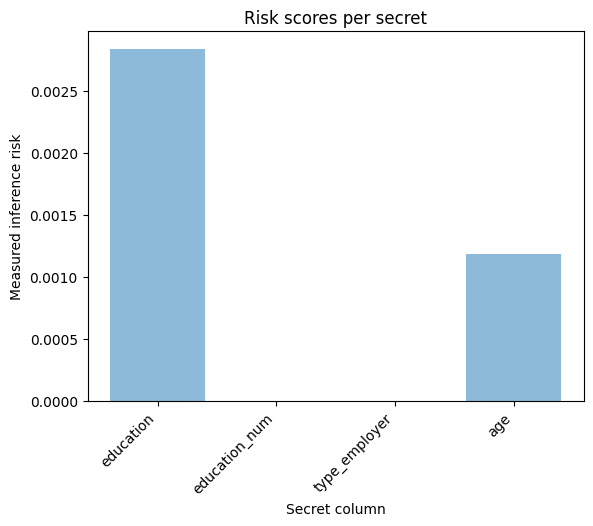

In [10]:
fig, ax = plt.subplots()

risks = [res[1].risk().value for res in results]
columns = [res[0] for res in results]

ax.bar(x=columns, height=risks, alpha=0.5, ecolor='black', capsize=10)

plt.xticks(rotation=45, ha='right')
plt.title("Risk scores per secret")
ax.set_ylabel("Measured inference risk")
_ = ax.set_xlabel("Secret column")

### Group-wise risk scores for each secret

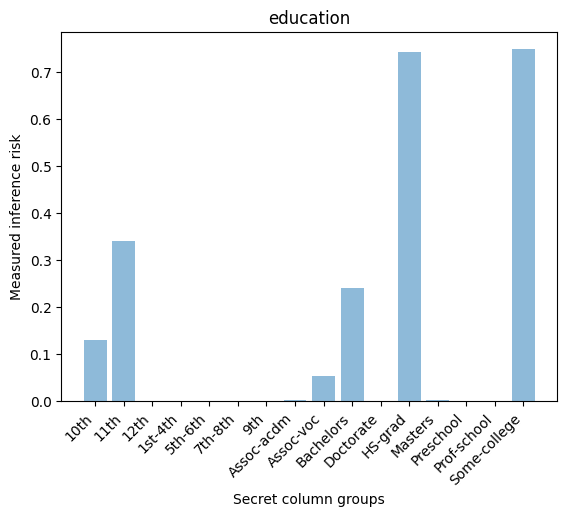

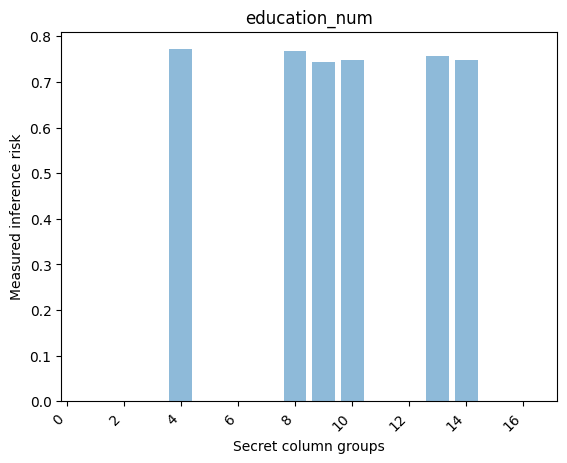

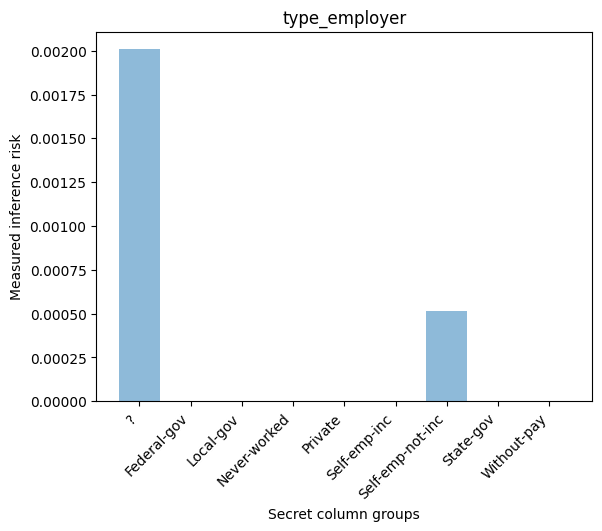

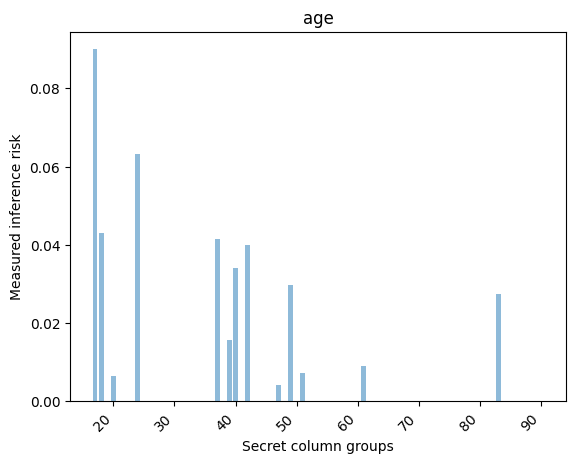

In [11]:
for secret in columns:
    curr_res = results_for_groups[secret]

    fig, ax = plt.subplots()

    risks = [res.risk().value for _, res in curr_res.items()]
    cols = [key for key,_ in curr_res.items()]

    ax.bar(x=cols, height=risks, alpha=0.5, ecolor='black', capsize=10)

    plt.xticks(rotation=45, ha='right')
    plt.title(secret)
    ax.set_ylabel("Measured inference risk")
    _ = ax.set_xlabel("Secret column groups")